In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [276]:
# Excel file
df_excel_csv = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# CSV file – FIXED
df_excel1 = pd.read_csv(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\historicaltrends_stock market.csv")

# Excel file
df_excel2 = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Api_Scripts\YahoFinance_Intraday Fetching\Sensex_Intraday_Data_2025-07-07.xlsx")



In [277]:
print(df_excel_csv.head())
print(df_excel1.head())
print(df_excel2.head())


   SNO       Date   Close    Open    High     Low Vol.  Change %  Year  \
0    1 1981-01-01  152.26  152.26  152.26  152.26  NaN    0.0270  1981   
1    2 1981-01-02  152.26  152.26  152.26  152.26  NaN    0.0270  1981   
2    3 1981-01-03   151.1   151.1   151.1   151.1  NaN   -0.0076  1981   
3    4 1981-01-04   151.1   151.1   151.1   151.1  NaN   -0.0076  1981   
4    5 1981-01-05   151.1   151.1   151.1   151.1  NaN   -0.0076  1981   

     Month  Day   Weekday  
0  January    1  Thursday  
1  January    2    Friday  
2  January    3  Saturday  
3  January    4    Sunday  
4  January    5    Monday  
                    Graphs  Year     Month  Day
0      Sensex Growth Phase  1986   January    2
1             Black Monday  1987   October   19
2  Economic Liberalization  1991      July    1
3          Market Collapse  1992     April   28
4      Budget Announcement  1997  February   28
   S.No   Time         Close          Open          High           Low
0     1  09:15  83367.960938

# Stock Market Analysis from 1981 to 2025

In [278]:
import pandas as pd
import plotly.express as px

# Use the correct DataFrame
df = df_excel_csv.copy()

# Convert 'Date' column to datetime and drop invalid ones
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Extract year
df['Year'] = df['Date'].dt.year

# Clean and convert 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').str.strip()
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

# Average close price per year
avg_close_per_year = df.groupby('Year', as_index=False)['Close'].mean()

# Plot interactive area chart
fig = px.area(
    avg_close_per_year,
    x='Year',
    y='Close',
    title="Stock Market Average Close Price (Interactive Area Chart)",
    markers=True
)

# Styling like your Jira graph
fig.update_traces(line_color='royalblue', marker=dict(size=6))
fig.update_layout(
    title=dict(
        text="Stock Market Average Close Price",
        x=0.5,
        xanchor='center',
        font=dict(family="Arial Black", size=20, color='black')
    ),
    xaxis=dict(
        title=dict(text='Year', font=dict(size=14, family="Arial Black", color='black')),
        tickfont=dict(size=12, family="Arial", color='black')
    ),
         yaxis=dict(
        title=dict(text='Average Close Price', font=dict(size=14, family="Arial Black", color='black')),
        tickfont=dict(size=12, family="Arial", color='black'),
        tickformat=','  # 👈 Ensures numbers like 10000 (not 10k)
    ),

    hovermode='x unified',
    template='plotly_white',
    legend_title_text='',
    showlegend=False
)
fig.update_layout(
    width=800,   # 🔁 Adjust width in pixels
    height=600,   # 🔁 Adjust height in pixels

)


fig.show()


# Overall Years High and Low Analysis

In [279]:
import pandas as pd
import plotly.express as px

# Load Excel data
df1 = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Preprocess Date column
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df1 = df1.dropna(subset=['Date'])
df1['Year'] = df1['Date'].dt.year

# Clean 'High' and 'Low'
for col in ['High', 'Low']:
    df1[col] = df1[col].astype(str).str.replace(',', '').str.strip()
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

df1 = df1.dropna(subset=['High', 'Low'])

# Calculate averages
avg_high_low = df1.groupby('Year')[['High', 'Low']].mean().reset_index()

# Reshape for horizontal Plotly Express bar chart
df_melted = avg_high_low.melt(id_vars='Year', value_vars=['High', 'Low'], 
                              var_name='Price Type', value_name='Average Price')

# Create horizontal bar chart with interactivity
fig = px.bar(
    df_melted,
    y='Year',
    x='Average Price',
    color='Price Type',
    orientation='h',
    color_discrete_map={
        'High': '#FFA500',  # orange
        'Low': '#87CEFA'    # skyblue
    },
    hover_data={
        'Year': True,
        'Price Type': True,
        'Average Price': ':.2f'
    },
    barmode='group',
    title="Stock Market High vs Low Price (Interactive Horizontal Chart)",
    height=800,
    width=1000
)

# Style the layout like your Jira chart
fig.update_layout(
    title=dict(
        text="Stock Market High vs Low Price ",
        x=0.5,
        xanchor='center',
        font=dict(size=20, family="Arial Black", color='black')
    ),
    xaxis=dict(
        title=dict(text='Average Price', font=dict(size=14, family="Arial Black", color='black')),
        tickfont=dict(size=12, family="Arial", color='black')
    ),
    yaxis=dict(
        title=dict(text='Year', font=dict(size=14, family="Arial Black", color='black')),
        tickfont=dict(size=12, family="Arial", color='black'),
        autorange='reversed'  # Latest year at bottom
    ),
    legend_title=dict(text="Price Type"),
    legend=dict(
        bgcolor='rgba(240,240,240,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(family="Arial Black", size=12, color="black")
    ),
    hovermode='y unified'
)
fig.update_layout(
    width=800,   # 🔁 Adjust width in pixels
    height=600,   # 🔁 Adjust height in pixels

)


fig.show()


# Profit and loss in Stock Market

In [280]:
import pandas as pd
import plotly.express as px

# Read Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year

# Filter for 1981, 2004, 2025
df_filtered = df[df['Year'].isin([1981, 2004, 2025])]

# Group and sum
sum_close_year = df_filtered.groupby('Year', as_index=False)['Close'].sum()

# Plotly Donut Chart
fig = px.pie(
    sum_close_year,
    names='Year',
    values='Close',
    hole=0.5,
    color_discrete_sequence=["#a2d7ac", '#99ff93', "#86E49D"],
)

# Update traces
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    insidetextfont=dict(family='Arial Black', size=14, color='black'),
    marker=dict(line=dict(color='white', width=2))
)

# Update layout
fig.update_layout(
    title=dict(
        text='Total Close Price Contribution (1981, 2004, 2025)',
        x=0.5,
        font=dict(family="Arial Black", size=20, color='black')
    ),
    legend=dict(
        title="Year",
        orientation="v",
        font=dict(size=12, color='black', family='Arial Black'),
        bordercolor='black',
        borderwidth=1,
        bgcolor='rgba(240,240,240,0.95)',
        itemsizing='constant'
    ),
    showlegend=True,
    template='plotly_white'
)

fig.update_layout(
    width=800,   # 🔁 Adjust width in pixels
    height=600,   # 🔁 Adjust height in pixels

)
fig.show()


# Future Forecast prediction

In [281]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\AKHILA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


16:07:51 - cmdstanpy - INFO - Chain [1] start processing
16:08:06 - cmdstanpy - INFO - Chain [1] done processing


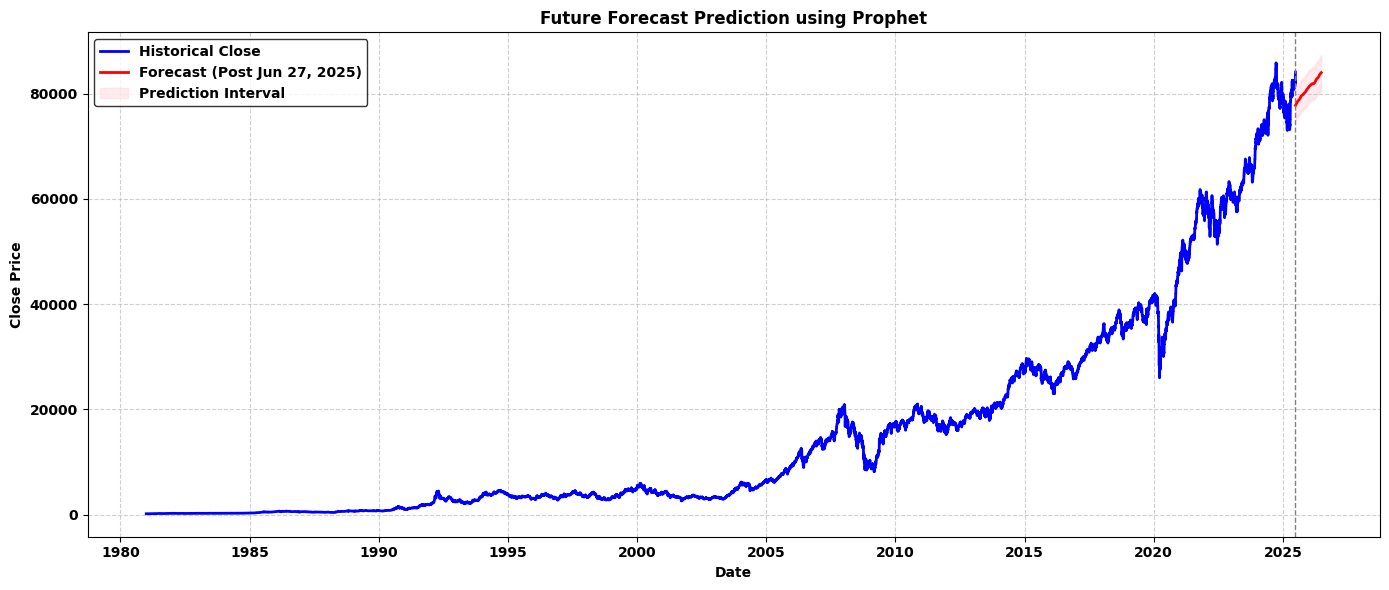

In [282]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Load dataset from Excel
df1 = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Ensure column names are consistent
df1.columns = df1.columns.str.strip()

# Convert 'Date' to datetime
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df1 = df1.dropna(subset=['Date'])

# Clean 'Close' column (remove commas, non-numeric values)
df1['Close'] = pd.to_numeric(
    df1['Close'].astype(str).str.replace('[^0-9.]', '', regex=True),
    errors='coerce'
)
df1 = df1.dropna(subset=['Close'])

# Prepare data for Prophet
prophet_df1 = df1[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Fit Prophet model
model = Prophet()
model.fit(prophet_df1)

# Create future DataFrame (365 days forecast)
forecast_days = 365
future = model.make_future_dataframe(periods=forecast_days, freq='D')
forecast = model.predict(future)

# Define cutoff date
cutoff_date = pd.to_datetime("2025-06-27")

# Split forecast into historical and future
historical_forecast = forecast[forecast['ds'] <= cutoff_date]
future_forecast = forecast[forecast['ds'] > cutoff_date]

# Plotting
plt.figure(figsize=(14, 6))

# Historical actual data
plt.plot(prophet_df1['ds'], prophet_df1['y'], color='blue', linewidth=2, label='Historical Close')

# Forecasted values
plt.plot(future_forecast['ds'], future_forecast['yhat'], color='red', linewidth=2, label='Forecast (Post Jun 27, 2025)')

# Prediction intervals
plt.fill_between(future_forecast['ds'],
                 future_forecast['yhat_lower'],
                 future_forecast['yhat_upper'],
                 color='pink', alpha=0.3, label='Prediction Interval')

# Vertical line at cutoff date
plt.axvline(cutoff_date, color='gray', linestyle='--', linewidth=1)

# Axis labels
plt.xlabel('Date', fontweight='bold', color='black')
plt.ylabel('Close Price', fontweight='bold', color='black')

# Axis tick values: bold and black
plt.tick_params(axis='both', labelcolor='black', labelsize=10)
for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

# Title
plt.title('Future Forecast Prediction using Prophet', fontweight='bold')

# Legend with square box and bold text
legend = plt.legend(
    loc='best',
    frameon=True,
    prop={'weight': 'bold', 'size': 10},
    title_fontproperties={'weight': 'bold'}
)
legend.get_frame().set_edgecolor('black')

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Save forecast to Excel
# forecast.to_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Forecast_Results.xlsx", index=False)

# June 2025 Stock Analysis

In [283]:
import pandas as pd
import plotly.graph_objects as go

# Load Excel
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Convert 'Date' and clean 'Close'
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Date', 'Close'])

# Filter for June 1 to June 27, 2025
mask = (df['Date'] >= '2025-06-01') & (df['Date'] <= '2025-06-27')
df_june = df.loc[mask].copy()

# Ensure all dates from June 1–27 are present
all_dates = pd.date_range(start='2025-06-01', end='2025-06-27')
df_june.set_index('Date', inplace=True)
df_june = df_june.reindex(all_dates)
df_june.index.name = 'Date'
df_june.reset_index(inplace=True)

# Plotly Line Chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_june['Date'],
    y=df_june['Close'],
    mode='lines+markers',
    line=dict(color='purple', width=2),
    marker=dict(size=6),
    name='Close Price'
))

# Layout Styling
fig.update_layout(
    title=dict(
        text='June 2025 Stock Close Price',
        x=0.5,
        font=dict(size=20, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title=dict(
            text='Date',
            font=dict(size=14, color='black', family='Arial Black')
        ),
        tickfont=dict(size=12, color='black', family='Arial'),
        tickangle=-45,
        tickmode='array',
        tickvals=df_june['Date'],
        ticktext=df_june['Date'].dt.strftime('%d-%b')
    ),
     yaxis=dict(
        title=dict(
            text='Close Price',
            font=dict(size=14, color='black', family='Arial Black')
        ),
        tickfont=dict(size=12, color='black', family='Arial'),
        tickformat=','  # ✅ Shows full number like 10000 instead of 10k
    ),
    template='plotly_white',
    hovermode='x unified',
    showlegend=False,
    width=800,
    height=600
)

fig.show()


# 1 Day Stock Price(May 07 2025)

In [284]:
import pandas as pd
import plotly.graph_objects as go

# File path
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Api_Scripts\YahoFinance_Intraday Fetching\Sensex_Intraday_Data_2025-07-07.xlsx"

# Read and clean
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Clean 'Close'
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Clean 'Time'
df['Time'] = pd.to_datetime(df['Time'].astype(str).str.strip(), errors='coerce').dt.strftime('%H:%M')
df = df.dropna(subset=['Time', 'Close'])

# Group by Time and take min close
min_close_by_time = df.groupby('Time')['Close'].min().reset_index()

# Create Plotly interactive chart (without data labels)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_by_time['Time'],
    y=min_close_by_time['Close'],
    mode='lines+markers',
    line=dict(color='green', width=2),
    marker=dict(size=6),
    name='Min Close'
))

# Layout styling
fig.update_layout(
    title=dict(
        text='1 Day Stock Price (July 07, 2025)',
        x=0.5,
        font=dict(size=18, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title=dict(
            text='Time',
            font=dict(size=14, color='black')
        ),
        tickangle=90,
        tickfont=dict(size=12, color='black')
    ),
        yaxis=dict(
        title=dict(
            text='Close Price',
            font=dict(size=14, color='black')
        ),
        tickfont=dict(size=12, color='black'),
        tickformat=','  # ✅ Show full numbers (e.g., 10000 not 10k)
    ),

    hovermode='x unified',
    template='plotly_white',
    margin=dict(l=50, r=50, t=60, b=100)
)
fig.update_layout(
    width=800,   # 🔁 Adjust width in pixels
    height=600,   # 🔁 Adjust height in pixels

)


fig.show()


C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\1418215975.py:16: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



# 1 Week Stock Prices (June 20 to June 27)

In [285]:
import pandas as pd
import plotly.graph_objects as go

# Load the Excel file
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Clean 'Close' values
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Drop missing 'Date' or 'Close'
df = df.dropna(subset=['Date', 'Close'])

# Filter for June 20 to June 27, 2025
start_date = pd.to_datetime('2025-06-20')
end_date = pd.to_datetime('2025-06-27')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Group by date and get close values
close_by_date = df_filtered.groupby(df_filtered['Date'].dt.date)['Close'].sum().reset_index()

# Create interactive Plotly chart (no labels)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=close_by_date['Date'],
    y=close_by_date['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=2),
    marker=dict(size=6),
    name='Close Price'
))

# Style the layout
fig.update_layout(
    title=dict(
        text='1 Week Stock Prices (June 20 to June 27, 2025)',
        x=0.5,
        font=dict(size=18, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title=dict(text='Date', font=dict(size=14, color='black')),
        tickangle=45,
        tickfont=dict(size=12, color='black')
    ),
    yaxis=dict(
        title=dict(text='Close Price', font=dict(size=14, color='black')),
        tickfont=dict(size=12, color='black'),
        tickformat=','  # 👈 This forces normal number format (e.g., 10500 instead of 10.5k)
    ),
    hovermode='x unified',
    template='plotly_white',
    margin=dict(l=50, r=50, t=60, b=100)
)
fig.update_layout(
    width=800,   # 🔁 Adjust width in pixels
    height=600,   # 🔁 Adjust height in pixels

)


fig.show()


# 1 Month Stock Prices (May 27 to June 27)

In [286]:
import pandas as pd
import plotly.graph_objects as go

# File path
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"

# Load Excel and clean columns
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Detect date column
date_col = None
for col in df.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col is None:
    raise ValueError("No column containing 'date' found.")

df.rename(columns={date_col: 'Date'}, inplace=True)

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['Date', 'Close'])

# Filter from May 27 to June 27, 2025
start_date = pd.to_datetime('2025-05-27')
end_date = pd.to_datetime('2025-06-27')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Group by day and calculate average Close
daily_avg = df_filtered.groupby(df_filtered['Date'].dt.date)['Close'].mean().reset_index()
daily_avg['Date'] = pd.to_datetime(daily_avg['Date'])

# Create interactive Plotly graph
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_avg['Date'],
    y=daily_avg['Close'],
    mode='lines+markers',
    line=dict(color='purple', width=2),
    marker=dict(size=6),
    name='Avg Close Price'
))

# Layout
fig.update_layout(
    title=dict(
        text='Stock Price (May 27 – June 27, 2025)',
        x=0.5,
        font=dict(size=20, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title=dict(text='Date', font=dict(size=14, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black'),
        tickangle=-45,
        tickformat='%b %d',
    ),
    yaxis=dict(
        title=dict(text='Average Close Price', font=dict(size=14, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black'),
        tickformat=',',  # 👈 This forces normal numeric formatting (e.g., 10500 instead of 10.5k)
    ),
    template='plotly_white',
    hovermode='x unified',
    showlegend=False,
    width=800,
    height=600
)

fig.show()


# 6 Months Stock prices (Jna 2025 to June 27 2025)

In [287]:
import pandas as pd
import plotly.graph_objects as go

# Load the Excel file
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Convert 'Date' and clean 'Close'
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Date', 'Close'])

# Filter data from Jan 1 to June 27, 2025
start_date = pd.Timestamp('2025-01-01')
end_date = pd.Timestamp('2025-06-27')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Monthly average
df_filtered['Month'] = df_filtered['Date'].dt.to_period('M')
monthly_avg_close = df_filtered.groupby('Month')['Close'].mean().reset_index()
monthly_avg_close['Month'] = monthly_avg_close['Month'].dt.to_timestamp()

# Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_avg_close['Month'],
    y=monthly_avg_close['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=2),
    marker=dict(size=6),
    name='Monthly Avg Close'
))

# Layout styling
fig.update_layout(
    title=dict(
        text='6 Months Stock Prices (Jan to June 27, 2025)',
        x=0.5,
        font=dict(size=18, color='black', family='Arial Black')
    ),
    xaxis=dict(
        title=dict(text='Month', font=dict(size=14, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black', family='Arial'),
        tickangle=45,
        tickmode='array',
        tickvals=monthly_avg_close['Month'],
        ticktext=monthly_avg_close['Month'].dt.strftime('%b %Y')
    ),
    yaxis=dict(
        title=dict(text='Close Price', font=dict(size=14, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black', family='Arial'),
        tickformat=','  # ✅ Full numeric values, not in 'k'
    ),
    hovermode='x unified',
    template='plotly_white',
    showlegend=False,
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=70, b=100)
)

fig.show()


# 1 Year Stock prices(June 2024 to June 2025)

In [288]:
import pandas as pd
import plotly.graph_objects as go

# Load Excel
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Clean columns and convert Date
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filter for June 2024 to June 2025
start_date = pd.Timestamp('2024-06-01')
end_date = pd.Timestamp('2025-06-27')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Clean 'Close' column
df_filtered['Close'] = df_filtered['Close'].astype(str).str.replace(',', '', regex=False)
df_filtered['Close'] = pd.to_numeric(df_filtered['Close'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Close'])

# Daily average close price
df_daily = df_filtered.groupby('Date')['Close'].mean().reset_index()

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_daily['Date'],
    y=df_daily['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=2),
    marker=dict(size=6),
    name='Daily Avg Close'
))

# Layout styling
fig.update_layout(
    title=dict(
        text='1 Year Stock Prices (June 2024 to June 2025)',
        x=0.5,
        font=dict(size=18, family='Arial Black', color='black')
    ),
    xaxis=dict(
        title=dict(text='Year-Month', font=dict(size=14, family='Arial Black', color='black')),
        tickfont=dict(size=12, family='Arial', color='black'),
        tickformat='%b %Y',
        tickangle=45
    ),
    yaxis=dict(
        title=dict(text='Close Price', font=dict(size=14, family='Arial Black', color='black')),
        tickfont=dict(size=12, family='Arial', color='black'),
        tickformat=','  # ✅ Full numeric values, no 'k'
    ),
    hovermode='x unified',
    template='plotly_white',
    showlegend=False,
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=70, b=100)
)

fig.show()


# 5 Years Stock prices(May 2021 to May 2025)

In [289]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Clean columns and convert 'Date'
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filter for June 2021 to June 2025
start_date = pd.Timestamp('2021-06-01')
end_date = pd.Timestamp('2025-06-30')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Clean 'Close' column
df_filtered['Close'] = df_filtered['Close'].astype(str).str.replace(',', '', regex=False)
df_filtered['Close'] = pd.to_numeric(df_filtered['Close'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Close'])

# Group by Date and compute average Close
df_daily = df_filtered.groupby('Date')['Close'].mean().reset_index()

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_daily['Date'],
    y=df_daily['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=2),
    marker=dict(size=5),
    name='Daily Avg Close'
))

# Layout styling
fig.update_layout(
    title=dict(
        text='5 Years Stock Prices (June 2021 to June 2025)',
        x=0.5,
        font=dict(size=18, family='Arial Black', color='black')
    ),
    xaxis=dict(
        title=dict(text='Year-Month', font=dict(size=14, family='Arial Black', color='black')),
        tickfont=dict(size=12, family='Arial', color='black'),
        tickformat='%b %Y',
        tickangle=45,
        dtick="M1",  # Set tick every month
        ticklabelmode='period'
    ),
    yaxis=dict(
        title=dict(text='Close Price', font=dict(size=14, family='Arial Black', color='black')),
        tickfont=dict(size=12, family='Arial', color='black'),
        tickformat=','  # ✅ Full numeric formatting (no 'k')
    ),
    hovermode='x unified',
    template='plotly_white',
    showlegend=False,
    width=900,   # Wider width for 5 years
    height=600,
    margin=dict(l=50, r=50, t=70, b=100)
)

fig.show()


# Stock flow

In [290]:
import pandas as pd
import plotly.graph_objects as go

# Load the dataset
file_path = r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx"
df = pd.read_excel(file_path)

# Clean and convert data
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract Year and Day
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day

# Filter for Day 1 to 30
df_filtered = df[df['Day'].between(1, 30)]

# Get minimum close per day per year
min_close_daywise = df_filtered.groupby(['Year', 'Day'])['Close'].min().reset_index()

# Pivot: Days as index, Years as columns
pivot_data = min_close_daywise.pivot(index='Day', columns='Year', values='Close')

# Create interactive plot
fig = go.Figure()

for year in pivot_data.columns:
    fig.add_trace(go.Scatter(
        x=pivot_data.index,
        y=pivot_data[year],
        mode='lines+markers',
        name=str(year),
        line=dict(width=2)
    ))

# Layout styling
fig.update_layout(
    title=dict(
        text='Trend Analysis of Stock Market (1981 to 2025)',
        x=0.5,
        font=dict(size=22, family='Arial Black', color='black')
    ),
    xaxis=dict(
        title=dict(text='Day', font=dict(size=16, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black'),
        dtick=5
    ),
    yaxis=dict(
        title=dict(text='Close Price', font=dict(size=16, color='black', family='Arial Black')),
        tickfont=dict(size=12, color='black'),
        tickformat=','  # ✅ Full numeric format
    ),
    legend=dict(
        title='Year',
        font=dict(size=10),
        orientation='v',
        x=1.02, y=0.5
    ),
    template='plotly_white',
    hovermode='x unified',
    width=800,
    height=600,
    margin=dict(l=50, r=150, t=80, b=80)
)

fig.show()


# Workday Distribution Over Time

In [291]:
import pandas as pd
import plotly.graph_objects as go

# Load the dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Create 'Weekday' column
df['Weekday'] = df['Date'].dt.day_name()

# Filter out weekends
working_days = df[~df['Weekday'].isin(['Saturday', 'Sunday'])].copy()

# Create 'Year' and 'Month' columns
working_days['Year'] = working_days['Date'].dt.year
working_days['Month'] = working_days['Date'].dt.month

# Group by Year and Month to count working days
working_days_per_month = working_days.groupby(['Year', 'Month']).size().reset_index(name='WorkingDays')

# Create a Plotly grouped bar chart
fig = go.Figure()

# Month names for x-axis
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot each year's data
years = sorted(working_days_per_month['Year'].unique())
for year in years:
    data = working_days_per_month[working_days_per_month['Year'] == year]
    fig.add_trace(go.Bar(
        x=[month_labels[m - 1] for m in data['Month']],
        y=data['WorkingDays'],
        name=str(year)
    ))

# Update layout
fig.update_layout(
    title=dict(
        text='Workday Distribution Over Time',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title=dict(text='Month', font=dict(size=16, color='black')),
        tickfont=dict(size=12, color='black')
    ),
    yaxis=dict(
        title=dict(text='Working Days', font=dict(size=16, color='black')),
        tickfont=dict(size=12, color='black'),
        dtick=2
    ),
    barmode='group',
    bargap=0.2,
    bargroupgap=0.1,
    legend=dict(
        title='Year',
        font=dict(size=10),
        x=1.02,
        y=1,
        orientation='v'
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=50, r=150, t=80, b=80)
)

# Show the plot
fig.show()


# Sensex Growth Phase

In [292]:
import pandas as pd
import plotly.graph_objs as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract year
df['Year'] = df['Date'].dt.year

# Filter for specific years
filtered_years = [1986, 1987, 1988, 1989, 1990]
df_filtered = df[df['Year'].isin(filtered_years)]

# Calculate min close per year
min_close_per_year = df_filtered.groupby('Year')['Close'].min().reset_index()

# Create Plotly line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_per_year['Year'],
    y=min_close_per_year['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='Minimum Close'
))

# Customize layout
fig.update_layout(
    title=dict(
        text='Sensex Growth Phase (1986–1990)',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Year',
        tickmode='array',
        tickvals=min_close_per_year['Year'],
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        dtick=50,
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


In [293]:
print("Unique Years:", df['Year'].unique())
print("1986 Entries:", df[df['Year'] == 1986].shape)
print("Sample 1986 Data:\n", df[df['Year'] == 1986].head())


Unique Years: [1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994
 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008
 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024 2025]
1986 Entries: (365, 12)
Sample 1986 Data:
        SNO       Date   Close    Open    High     Low Vol.  Change %  Year  \
1826  1827 1986-01-01  527.36  527.36  527.36  527.36  NaN    0.0108  1986   
1827  1828 1986-01-02  549.43  549.43  549.43  549.43  NaN    0.0418  1986   
1828  1829 1986-01-03  561.01  561.01  561.01  561.01  NaN    0.0211  1986   
1829  1830 1986-01-04  561.01  561.01  561.01  561.01  NaN    0.0211  1986   
1830  1831 1986-01-05  561.01  561.01  561.01  561.01  NaN    0.0211  1986   

        Month  Day    Weekday  
1826  January    1  Wednesday  
1827  January    2   Thursday  
1828  January    3     Friday  
1829  January    4   Saturday  
1830  January    5     Sunday  


In [294]:
import pandas as pd
import plotly.graph_objs as go

# Load the dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()

# Convert 'Date' to datetime and extract 'Year' and 'Month'
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Convert 'Close' to numeric
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Filter for 1986
df_1986 = df[df['Year'] == 1986]

# Group by Month and get minimum Close
monthly_min_close = df_1986.groupby('Month')['Close'].min().sort_index()

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x_labels = [month_labels[m - 1] for m in monthly_min_close.index]

# Create Plotly interactive figure
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_labels,
    y=monthly_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='Min Close'
))

# Layout update
fig.update_layout(
    title=dict(
        text='In Year 1986',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(title='Month', tickfont=dict(size=14, color='black')),
    yaxis=dict(title='Close Price', tickfont=dict(size=14, color='black')),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


In [295]:
import pandas as pd
import plotly.graph_objs as go

# Load the dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Ensure 'Close' is numeric
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract Year and Month if missing
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop missing rows
df = df.dropna(subset=['Year', 'Month', 'Close'])

# Filter for 1987
df_1987 = df[df['Year'] == 1987]

# Group by Month and get minimum Close
monthly_min_close = df_1987.groupby('Month')['Close'].min().sort_index()

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Get month names corresponding to the grouped data
month_names = [month_labels[int(m)-1] for m in monthly_min_close.index]

# Create interactive Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=month_names,
    y=monthly_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='Min Close'
))

# Update layout
fig.update_layout(
    title=dict(
        text='In Year 1987',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


In [296]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go

# Load the dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Ensure 'Close' is numeric
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop rows with missing values
df = df.dropna(subset=['Year', 'Month', 'Close'])

# Filter for 1988
df_1988 = df[df['Year'] == 1988]

# Group by Month and get minimum Close price
monthly_min_close = df_1988.groupby('Month')['Close'].min()

# Ensure all 12 months are present (fill missing with NaN)
all_months = pd.Series(np.arange(1, 13), name='Month')
monthly_min_close = monthly_min_close.reindex(all_months)

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create interactive Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=month_labels,
    y=monthly_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='Min Close'
))

# Update layout
fig.update_layout(
    title=dict(
        text='In Year 1988',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


In [297]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go

# Load your actual dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Ensure 'Close' is numeric
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime and extract Year, Month
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Drop rows with missing values
df = df.dropna(subset=['Date', 'Close', 'Year', 'Month'])

# Filter data for 1989
df_1989 = df[df['Year'] == 1989]

# Group by Month and get minimum close price
monthly_min_close = df_1989.groupby('Month')['Close'].min()

# Ensure all 12 months are present
all_months = pd.Series(np.arange(1, 13), name='Month')
monthly_min_close = monthly_min_close.reindex(all_months)

# Month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create interactive Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=months,
    y=monthly_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='Min Close'
))

# Update layout
fig.update_layout(
    title=dict(
        text='In Year 1989',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


In [298]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go

# Load the dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean column names
df.columns = df.columns.str.strip()

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime and extract Year and Month
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 1990 data
df_1990 = df[df['Year'] == 1990]

# Drop rows with NaNs
df_1990 = df_1990.dropna(subset=['Close', 'Month'])

# Group by Month and get min Close
monthly_min_close = df_1990.groupby('Month')['Close'].min().reindex(range(1, 13), fill_value=np.nan)

# Month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Interactive Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=months,
    y=monthly_min_close.values,
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=8),
    name='Min Close'
))

# Layout
fig.update_layout(
    title=dict(
        text='In Year 1990',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


# Black Monday

In [299]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean columns
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter for October 1987
oct_1987 = df[(df['Year'] == 1987) & (df['Month'] == 10)]

# Group by Day and get min Close
daily_min_close = oct_1987.groupby('Day')['Close'].min()

# Highlight values
highlight_day = 19
highlight_price = daily_min_close.loc[highlight_day]

# Create Plotly figure
fig = go.Figure()

# Line and markers (no trace name shown)
fig.add_trace(go.Scatter(
    x=daily_min_close.index,
    y=daily_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    name='',  # remove trace name
    hovertemplate='Day: %{x}<br>Close: %{y:.2f}<extra></extra>',  # clean hover
    showlegend=False
))

# Red highlight for 19th Oct
fig.add_trace(go.Scatter(
    x=[highlight_day],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12, symbol='circle'),
    name='',
    hovertemplate='Day: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

fig.add_annotation(
    x=highlight_day,
    y=highlight_price,
    text="Black Monday",
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-60,
    font=dict(
        size=16,
        color='black',
        family='Arial Black'  # Makes it bold
    ),
    arrowcolor='red',
    arrowsize=2.5
)

# Layout
fig.update_layout(
    title=dict(
        text='Black Monday in October 1987',
        font=dict(size=22, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Day',
        tickmode='linear',
        dtick=1,
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60),
    showlegend=False
)

fig.show()


In [300]:
import pandas as pd
import plotly.graph_objs as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and extract date components
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Target days around Black Monday
target_days = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
oct_1987 = df[(df['Year'] == 1987) & (df['Month'] == 10) & (df['Day'].isin(target_days))]

# Group by Day and get minimum Close
daily_min_close = oct_1987.groupby('Day')['Close'].min()

# Prepare Plotly figure
fig = go.Figure()

# Line plot without trace label
fig.add_trace(go.Scatter(
    x=daily_min_close.index,
    y=daily_min_close.values,
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    hovertemplate='Day: %{x}<br>Close: %{y:.2f}<extra></extra>',  # Removes trace label
    showlegend=False
))

# Highlight 19 Oct 1987
highlight_day = 19
if highlight_day in daily_min_close.index:
    highlight_price = daily_min_close.loc[highlight_day]

    # Red dot on 19th
    fig.add_trace(go.Scatter(
        x=[highlight_day],
        y=[highlight_price],
        mode='markers',
        marker=dict(color='red', size=12, symbol='circle'),
        hovertemplate='19 Oct 1987<br>Close: %{y:.2f}<extra></extra>',
        showlegend=False
    ))

    # Annotation with arrow
    fig.add_annotation(
        x=highlight_day,
        y=highlight_price,
        text="<b>Black Monday</b>",
        showarrow=True,
        arrowhead=3,
        ax=0,
        ay=-60,
        font=dict(size=14, color='black'),
        arrowcolor='red',
        arrowsize=2
    )

# Layout styling
fig.update_layout(
    title=dict(
        text='Black Monday Week Analysis (October 1987)',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Day',
        tickmode='linear',
        dtick=1,
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


# Economic Liberalization

In [301]:
import pandas as pd
import plotly.graph_objs as go

# Read data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column (remove commas and convert to float)
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract year
df['Year'] = df['Date'].dt.year

# Filter for years 1990–1995
filtered_years = [1990, 1991, 1992, 1993, 1994, 1995]
df_filtered = df[df['Year'].isin(filtered_years)]

# Group by year and get minimum close value
min_close_per_year = df_filtered.groupby('Year')['Close'].min().reset_index()

# Highlight 1991
highlight_year = 1991
highlight_price = min_close_per_year[min_close_per_year['Year'] == highlight_year]['Close'].values[0]

# Create interactive plot
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=min_close_per_year['Year'],
    y=min_close_per_year['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    hovertemplate='Year: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Red highlight for 1991
fig.add_trace(go.Scatter(
    x=[highlight_year],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12, symbol='circle'),
    hovertemplate='Year: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation for 1991
fig.add_annotation(
    x=highlight_year,
    y=highlight_price,
    text="Economic Liberalization",
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='black', family='Arial Black'),
    arrowcolor='red',
    arrowsize=2.5
)

# Layout customization
fig.update_layout(
    title=dict(
        text='Economic Liberalization',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Year',
        tickmode='linear',
        tickvals=min_close_per_year['Year'],
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        range=[500, 3500],
        tickvals=list(range(500, 3600, 500)),
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60),
    showlegend=False
)

fig.show()


In [302]:
import pandas as pd
import plotly.graph_objs as go
import calendar

# Read data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract year and month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 1991
df_1991 = df[df['Year'] == 1991]

# Group by month and get min close
min_close_per_month = df_1991.groupby('Month')['Close'].min().reset_index()

# Add month name
min_close_per_month['Month_Name'] = min_close_per_month['Month'].apply(lambda x: calendar.month_abbr[x])

# Extract July point
highlight_month = 'Jul'
highlight_price = min_close_per_month[min_close_per_month['Month_Name'] == highlight_month]['Close'].values[0]

# Create Plotly figure
fig = go.Figure()

# Line + marker
fig.add_trace(go.Scatter(
    x=min_close_per_month['Month_Name'],
    y=min_close_per_month['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=8),
    hovertemplate='Month: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight July
fig.add_trace(go.Scatter(
    x=[highlight_month],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=14, symbol='circle'),
    hovertemplate='Month: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation for July
fig.add_annotation(
    x=highlight_month,
    y=highlight_price,
    text="Economic Liberalization",
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red', family='Arial Black'),
    arrowcolor='red',
    arrowsize=2.5
)

# Layout
fig.update_layout(
    title=dict(
        text='Economic Liberalization in year 1991',
        font=dict(size=20, family='Arial Black', color='black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickmode='array',
        tickvals=min_close_per_month['Month_Name'],
        tickfont=dict(size=14, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=14, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60),
    showlegend=False
)

fig.show()


# India’s 1992 Market Collapse

In [303]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df1 = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare data
df1.columns = df1.columns.str.strip()
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df1['Close'] = df1['Close'].astype(str).str.replace(',', '', regex=False)
df1['Close'] = pd.to_numeric(df1['Close'], errors='coerce')

# Filter data for March to May 1992
mask = (df1['Date'] >= '1992-03-01') & (df1['Date'] <= '1992-05-31')
df_filtered = df1.loc[mask].copy().sort_values('Date')

# Highlight April 28, 1992
highlight_date = pd.to_datetime('1992-04-28')
highlight_row = df_filtered[df_filtered['Date'] == highlight_date]

# Create figure
fig = go.Figure()

# Area fill (using 'scatter' with fill)
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines',
    line=dict(color='blue', width=2),
    fill='tozeroy',
    fillcolor='rgba(135, 206, 250, 0.5)',  # skyblue with alpha
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight April 28 marker
if not highlight_row.empty:
    x = highlight_date
    y = highlight_row['Close'].values[0]

    fig.add_trace(go.Scatter(
        x=[x],
        y=[y],
        mode='markers',
        marker=dict(color='red', size=14, symbol='triangle-down'),
        hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
        showlegend=False
    ))

    # Annotation
    fig.add_annotation(
        x=x,
        y=y,
        text='Market Collapse<br>(April 28, 1992)',
        showarrow=True,
        arrowhead=2,
        arrowsize=2,
        ax=0,
        ay=150,
        font=dict(size=14, color='red', family='Arial Black'),
        arrowcolor='black'
    )

# Layout formatting
fig.update_layout(
    title=dict(
        text='India’s 1992 Market Collapse',
        font=dict(size=24, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickmode='array',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=13, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=13, color='black')
    ),
    template='plotly_white',
    width=1000,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Budget Announcement

In [304]:
import pandas as pd
import plotly.graph_objs as go

# Read data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract year, month, day
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter for Feb-Apr 1997, days 1–30
df_filtered = df[
    (df['Year'] == 1997) &
    (df['Month'].isin([2, 3, 4])) &
    (df['Day'].between(1, 30))
]

# Group and create 'Date'
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])
min_close_daywise = min_close_daywise.sort_values('Date')

# Highlight Feb 28, 1997
highlight_date = pd.Timestamp('1997-02-28')
highlight_price = min_close_daywise[min_close_daywise['Date'] == highlight_date]['Close'].values[0]

# Create figure
fig = go.Figure()

# Line plot
fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=8),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight marker
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=14, symbol='circle'),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation for Budget Day
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Budget Day',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-120,
    font=dict(size=14, color='red', family='Arial Black'),
    arrowcolor='red',
    arrowsize=2
)

# Layout
fig.update_layout(
    title=dict(
        text='Budget Announcement',
        font=dict(size=22, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Day, Month',
        tickvals=min_close_daywise['Date'],
        ticktext=min_close_daywise['Date'].dt.strftime('%b %d'),
        tickangle=60,
        tickfont=dict(size=12, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=13, color='black')
    ),
    template='plotly_white',
    width=1000,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Asian Financial Crisis

In [305]:
import pandas as pd
import plotly.graph_objs as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 1997–1999
df_filtered = df[df['Year'].isin([1997, 1998, 1999])]

# Group by Year-Month and get min Close
min_close_monthly = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthly['Year-Month'] = pd.to_datetime(min_close_monthly[['Year', 'Month']].assign(DAY=1))
min_close_monthly = min_close_monthly.sort_values('Year-Month')

# Highlight August 1998
highlight_date = pd.to_datetime('1998-08-01')
highlight_point = min_close_monthly[min_close_monthly['Year-Month'] == highlight_date]

# Create figure
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=min_close_monthly['Year-Month'],
    y=min_close_monthly['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=8),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight marker
if not highlight_point.empty:
    y = highlight_point['Close'].values[0]

    fig.add_trace(go.Scatter(
        x=[highlight_date],
        y=[y],
        mode='markers',
        marker=dict(color='red', size=14, symbol='circle'),
        hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
        showlegend=False
    ))

    # Annotation
    fig.add_annotation(
        x=highlight_date,
        y=y,
        text='Asian Financial Crisis',
        showarrow=True,
        arrowhead=3,
        ax=0,
        ay=-180,
        font=dict(size=14, color='red', family='Arial Black'),
        arrowcolor='red',
        arrowsize=2
    )

# Layout
fig.update_layout(
    title=dict(
        text='Asian Financial Crisis',
        font=dict(size=22, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Year-Month',
        tickvals=min_close_monthly['Year-Month'],
        ticktext=min_close_monthly['Year-Month'].dt.strftime('%Y-%b'),
        tickangle=45,
        tickfont=dict(size=13, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickvals=list(range(3000, 9000, 500)),
        range=[
            min(min_close_monthly['Close']) - 500,
            max(min_close_monthly['Close']) + 800
        ],
        tickfont=dict(size=13, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


In [306]:
import pandas as pd
import plotly.graph_objs as go

# Read dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract date parts
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter August 1998
df_filtered = df[(df['Year'] == 1998) & (df['Month'] == 8)]
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])

# Create full date range
full_dates = pd.date_range(start='1998-08-01', end='1998-08-31')
full_df = pd.DataFrame({'Date': full_dates})
full_df['Year'] = full_df['Date'].dt.year
full_df['Month'] = full_df['Date'].dt.month
full_df['Day'] = full_df['Date'].dt.day

# Merge and interpolate
merged = pd.merge(full_df, min_close_daywise[['Year', 'Month', 'Day', 'Close']], 
                  on=['Year', 'Month', 'Day'], how='left')
merged['Close_interp'] = merged['Close'].interpolate(method='linear')

# Highlight 31 Aug
highlight_date = pd.Timestamp('1998-08-31')
highlight_price = merged.loc[merged['Date'] == highlight_date, 'Close_interp'].values[0]

# Plotly figure
fig = go.Figure()

# Line plot with markers
fig.add_trace(go.Scatter(
    x=merged['Date'],
    y=merged['Close_interp'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=14, symbol='circle'),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotate
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Asian Financial Crisis',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red', family='Arial Black'),
    arrowcolor='red',
    arrowsize=2
)

# Layout
fig.update_layout(
    title=dict(
        text='Asian Financial Crisis in the Month of August',
        font=dict(size=22, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Day',
        tickvals=merged['Date'],
        ticktext=merged['Day'].astype(str),
        tickangle=45,
        tickfont=dict(size=13, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=13, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Kargil War

In [307]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter Apr–Jul 1999
df_filtered = df[
    (df['Year'] == 1999) & 
    (df['Month'].isin([4, 5, 6, 7])) &
    (df['Day'].between(1, 30))
]

# Group and get minimum close per day
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])
min_close_daywise = min_close_daywise.sort_values('Date')

# Create full range from Apr 1 to Jul 30, 1999
full_range = pd.date_range(start='1999-04-01', end='1999-07-30')
min_close_daywise = min_close_daywise.set_index('Date').reindex(full_range).rename_axis('Date').reset_index()
min_close_daywise['Close'] = min_close_daywise['Close'].interpolate()

# Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers',
    line=dict(color='purple', width=2),
    marker=dict(size=6),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Layout
fig.update_layout(
    title=dict(
        text='Kargil War',
        font=dict(size=22, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Day',
        tickvals=min_close_daywise['Date'][::3],  # Show every 3rd day to avoid clutter
        ticktext=[d.strftime('%b %d') for d in min_close_daywise['Date'][::3]],
        tickangle=90,
        tickfont=dict(size=10, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=12, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


In [308]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter May 1999
start_date = pd.Timestamp('1999-05-01')
end_date = pd.Timestamp('1999-05-31')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
df_filtered = df_filtered.sort_values('Date')

# Highlight May 3
highlight_date = pd.Timestamp('1999-05-03')
highlight_price = df_filtered.loc[df_filtered['Date'] == highlight_date, 'Close'].values[0]

# Plotly figure
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='darkgreen', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Kargil War',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Kargil War in May 1999',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Dot-Com Bubble

In [309]:
import pandas as pd
import plotly.graph_objs as go

# Read data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2000–2002 and get the first trading day per month
df_filtered = df[df['Year'].isin([2000, 2001, 2002])].sort_values('Date')
month_start_close = df_filtered.groupby(['Year', 'Month']).first().reset_index()

# Add 'YearMonth' column for x-axis labels
month_start_close['YearMonth'] = month_start_close['Date'].dt.strftime('%Y-%b')

# Plotly figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=month_start_close['YearMonth'],
    y=month_start_close['Close'],
    mode='lines+markers',
    line=dict(color='darkorange', width=3),
    marker=dict(size=7),
    hovertemplate='Month: %{x}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Layout
fig.update_layout(
    title=dict(
        text='Dot-Com Bubble',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Year-Month',
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


In [310]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Filter for 2001
df_2001 = df[(df['Date'] >= '2001-01-01') & (df['Date'] <= '2001-12-31')].copy()

# Create Year-Month period
df_2001['YearMonth'] = df_2001['Date'].dt.to_period('M')
df_monthly = df_2001.groupby('YearMonth')['Close'].mean().reset_index()
df_monthly['YearMonth'] = df_monthly['YearMonth'].dt.to_timestamp()
df_monthly['Month_Label'] = df_monthly['YearMonth'].dt.strftime('%b')

# Locate September 2001
highlight_month = 'Sep'
highlight_row = df_monthly[df_monthly['Month_Label'] == highlight_month]

# Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_monthly['Month_Label'],
    y=df_monthly['Close'],
    mode='lines+markers',
    line=dict(color='darkblue', width=3),
    marker=dict(size=7),
    hovertemplate='Month: %{x}<br>Avg Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight September 2001
if not highlight_row.empty:
    x = highlight_row['Month_Label'].values[0]
    y = highlight_row['Close'].values[0]

    fig.add_trace(go.Scatter(
        x=[x],
        y=[y],
        mode='markers+text',
        marker=dict(color='red', size=12),
        textposition='top center',
        hovertemplate='Month: %{x}<br>Avg Close: %{y:.2f}<extra></extra>',
        showlegend=False
    ))

    fig.add_annotation(
    x=x,
    y=y,
    text='Dot-Com Bubble',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-150,  # <-- moved up
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(text='Dot-com Bubble Analysis in 2001', font=dict(size=20, family='Arial Black'), x=0.5),
    xaxis=dict(title='Month', tickfont=dict(size=12, color='black')),
    yaxis=dict(title='Close Price', tickfont=dict(size=12, color='black')),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=60)
)

fig.show()


# UPA Election Shock

In [311]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Filter for April and May 2004
df_filtered = df[
    (df['Date'].dt.year == 2004) &
    (df['Date'].dt.month.isin([4, 5])) &
    (df['Date'].dt.day.between(1, 30))
]

# Group by day and take minimum Close price
df_filtered['Year'] = df_filtered['Date'].dt.year
df_filtered['Month'] = df_filtered['Date'].dt.month
df_filtered['Day'] = df_filtered['Date'].dt.day
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])
min_close_daywise = min_close_daywise.sort_values('Date')

# Highlight 17 May 2004
highlight_date = pd.Timestamp('2004-05-17')
highlight_row = min_close_daywise[min_close_daywise['Date'] == highlight_date]

# Build Plotly chart
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers',
    line=dict(color='green', width=2),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    name='Close Price'
))

# Highlight point
if not highlight_row.empty:
    x = highlight_date
    y = highlight_row['Close'].values[0]

    fig.add_trace(go.Scatter(
        x=[x],
        y=[y],
        mode='markers+text',
        marker=dict(color='red', size=12),
        text=['17 May 2004'],
        textposition='top center',
        hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
        showlegend=False
    ))

    fig.add_annotation(
        x=x,
        y=y,
        text='UPA Election Shock',
        showarrow=True,
        arrowhead=3,
        ax=0,
        ay=-250,
        font=dict(size=13, color='red'),
        arrowcolor='red'
    )

# Final layout
fig.update_layout(
    title=dict(text='UPA Election Shock (Apr–May 2004)', font=dict(size=20, family='Arial Black'), x=0.5),
    xaxis=dict(
        title='Date',
        tickmode='array',
        tickvals=min_close_daywise['Date'],
        ticktext=min_close_daywise['Date'].dt.strftime('%b %d'),
        tickangle=90,
        tickfont=dict(size=10, color='black')
    ),
    yaxis=dict(
        title='Minimum Close Price',
        tickfont=dict(size=12, color='black')
    ),
    template='plotly_white',
    width=1000,
    height=500,
    margin=dict(l=60, r=40, t=80, b=100)
)

fig.show()


C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\3191430244.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\3191430244.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\3191430244.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

# Global Financial Crisis

In [312]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '', regex=False)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Filter for year 2008
df_filtered = df[df['Date'].dt.year == 2008].copy()

# Group by month and get min close
df_filtered['Month'] = df_filtered['Date'].dt.month
df_filtered['Year'] = df_filtered['Date'].dt.year
monthly_min = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
monthly_min['Date'] = pd.to_datetime(monthly_min[['Year', 'Month']].assign(Day=1))
monthly_min = monthly_min.sort_values('Date')

# Highlight October 2008
highlight_date = pd.Timestamp('2008-10-01')
highlight_row = monthly_min[monthly_min['Date'] == highlight_date]

# Create plot
fig = go.Figure()

# Line chart (no legend)
fig.add_trace(go.Scatter(
    x=monthly_min['Date'],
    y=monthly_min['Close'],
    mode='lines+markers',
    line=dict(color='darkred', width=2),
    marker=dict(size=7),
    showlegend=False,
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>'
))

# Highlight October 2008
if not highlight_row.empty:
    x = highlight_row['Date'].values[0]
    y = highlight_row['Close'].values[0]
    
    fig.add_trace(go.Scatter(
        x=[x],
        y=[y],
        mode='markers+text',
        marker=dict(color='red', size=12),
        text=['Oct 2008'],
        textposition='top center',
        showlegend=False,
        hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>'
    ))

    fig.add_annotation(
        x=x,
        y=y,
        text='Global Financial Crisis',
        showarrow=True,
        arrowhead=3,
        ax=0,
        ay=-2000,
        font=dict(size=13, color='red'),
        arrowcolor='red'
    )

# Layout
fig.update_layout(
    title='Global Financial Crisis (2008)',
    title_font=dict(size=20, family='Arial Black'),
    showlegend=False,
    xaxis=dict(
        title='Month',
        tickmode='array',
        tickvals=monthly_min['Date'],
        ticktext=monthly_min['Date'].dt.strftime('%b'),
        tickangle=0,
        tickfont=dict(size=12, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=12, color='black')
    ),
    width=950,
    height=500,
    template='plotly_white',
    margin=dict(l=60, r=40, t=80, b=80)
)

fig.show()


In [313]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter October 2008
start_date = pd.Timestamp('2008-10-01')
end_date = pd.Timestamp('2008-10-30')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
df_filtered = df_filtered.sort_values('Date')

# Highlight October 24, 2008
highlight_date = pd.Timestamp('2008-10-24')
highlight_price = df_filtered.loc[df_filtered['Date'] == highlight_date, 'Close'].values[0]

# Plotly figure
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Global Financial Crisis',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-180,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Global Financial Crisis (October 2008)',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Biggest Single Day Gain

In [314]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter May 2009
start_date = pd.Timestamp('2009-05-01')
end_date = pd.Timestamp('2009-05-30')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
df_filtered = df_filtered.sort_values('Date')

# Highlight May 18
highlight_date = pd.Timestamp('2009-05-18')
highlight_price = df_filtered.loc[df_filtered['Date'] == highlight_date, 'Close'].values[0]

# Plotly figure
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='darkorange', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Biggest Single Day Gain',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Biggest Single Day Gain in May 2009',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black'),
        tickformat=',d'  # <-- This ensures full numeric values (no K)
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# NDA Victory

In [315]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter Jan to June 2014
df_filtered = df[(df['Date'].dt.year == 2014) & (df['Date'].dt.month <= 6)].copy()
df_filtered['Month'] = df_filtered['Date'].dt.month
df_filtered['Year'] = df_filtered['Date'].dt.year

# Group by month and get min close
monthly_min = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
monthly_min['Date'] = pd.to_datetime(dict(year=monthly_min['Year'], month=monthly_min['Month'], day=1))

# Highlight point - May 2014
highlight_date = pd.Timestamp('2014-05-01')
highlight_price = monthly_min.loc[monthly_min['Date'] == highlight_date, 'Close'].values[0]

# Plot
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=monthly_min['Date'],
    y=monthly_min['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='NDA Victory',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='NDA Victory',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month',
        tickvals=monthly_min['Date'],
        ticktext=monthly_min['Date'].dt.strftime('%b %Y'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black'),
        tickformat=',d'  # <-- Show full numeric values (no 'K')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


In [316]:
import pandas as pd
import plotly.graph_objs as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter May 2014
df_filtered = df[(df['Date'].dt.year == 2014) & (df['Date'].dt.month == 5)]
df_filtered = df_filtered.copy()
df_filtered = df_filtered[df_filtered['Date'].dt.day.between(1, 30)]

# Group to get minimum close per day
df_filtered['Day'] = df_filtered['Date'].dt.day
min_close_daywise = df_filtered.groupby('Day')['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime({'year': 2014, 'month': 5, 'day': min_close_daywise['Day']})
min_close_daywise = min_close_daywise[['Date', 'Close']].set_index('Date')

# Reindex with full May date range and interpolate missing
full_range = pd.date_range(start='2014-05-01', end='2014-05-30')
min_close_daywise = min_close_daywise.reindex(full_range)
min_close_daywise['Close'] = min_close_daywise['Close'].interpolate()
min_close_daywise = min_close_daywise.reset_index().rename(columns={'index': 'Date'})

# Highlight point
highlight_date = pd.Timestamp('2014-05-16')
highlight_price = min_close_daywise.loc[min_close_daywise['Date'] == highlight_date, 'Close'].values[0]

# Plot
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='NDA Victory',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-120,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='NDA Victory in May Month',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=min_close_daywise['Date'],
        ticktext=min_close_daywise['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickformat=',d',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=800,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Formation Day

In [317]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter 2013-2015
df_filtered = df[df['Date'].dt.year.isin([2013, 2014, 2015])]

# Group by Year-Month to get minimum close
df_filtered['YearMonth'] = df_filtered['Date'].dt.to_period('M')
min_close_monthly = df_filtered.groupby('YearMonth')['Close'].min().reset_index()
min_close_monthly['YearMonth'] = min_close_monthly['YearMonth'].dt.to_timestamp()

# Reindex for continuous months
full_range = pd.date_range(start='2013-01-01', end='2015-12-01', freq='MS')
min_close_monthly = min_close_monthly.set_index('YearMonth').reindex(full_range).rename_axis('YearMonth').reset_index()
min_close_monthly['Close'] = min_close_monthly['Close'].interpolate()

# Plotly figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthly['YearMonth'],
    y=min_close_monthly['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=7),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y}<extra></extra>',
    showlegend=False
))

# Layout
fig.update_layout(
    title=dict(
        text='Formation Day',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Year-Month',
        tickvals=min_close_monthly['YearMonth'],
        ticktext=min_close_monthly['YearMonth'].dt.strftime('%Y-%b'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickformat=',d',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\2501813310.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [318]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter June 2014
df_filtered = df[(df['Date'].dt.year == 2014) & (df['Date'].dt.month == 6)].copy()
df_filtered = df_filtered.sort_values('Date')

# Create full date range for June 2014
full_range = pd.date_range(start='2014-06-01', end='2014-06-30')
df_filtered = df_filtered.set_index('Date').reindex(full_range).rename_axis('Date').reset_index()
df_filtered['Close'] = df_filtered['Close'].interpolate()

# Highlight June 2, 2014
highlight_date = pd.Timestamp('2014-06-02')
highlight_price = df_filtered[df_filtered['Date'] == highlight_date]['Close'].values[0]

# Plotly figure
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Formation Day',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Formation Day - June 2014',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickformat=',d',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# US Elections

In [319]:
import pandas as pd
import plotly.graph_objs as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter Oct to Dec 2016
df_filtered = df[(df['Date'].dt.year == 2016) & (df['Date'].dt.month.isin([10, 11, 12]))].copy()
df_filtered = df_filtered.sort_values('Date')

# Create full date range and interpolate missing values
date_range = pd.date_range(start='2016-10-01', end='2016-12-30')
df_filtered = df_filtered.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
df_filtered['Close'] = df_filtered['Close'].interpolate()

# Highlight: November 8, 2016
highlight_date = pd.Timestamp('2016-11-08')
highlight_price = df_filtered[df_filtered['Date'] == highlight_date]['Close'].values[0]

# Plotly chart
fig = go.Figure()

# Main line
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=6),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='US Election',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='US Elections - November 2016',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%d-%b'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickformat=',d',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=950,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Demonetization Analysis-2016

In [320]:
import pandas as pd
import plotly.graph_objs as go

# Read and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter for Oct 1 to Dec 30, 2016
start_date = pd.Timestamp('2016-10-01')
end_date = pd.Timestamp('2016-12-30')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
df_filtered = df_filtered.sort_values('Date')

# Fill missing dates
date_range = pd.date_range(start=start_date, end=end_date)
df_filtered = df_filtered.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
df_filtered['Close'] = df_filtered['Close'].interpolate()

# Highlight date
highlight_date = pd.Timestamp('2016-11-08')
highlight_price = df_filtered.loc[df_filtered['Date'] == highlight_date, 'Close'].values[0]

# Create plotly figure
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Demonetization',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout styling
fig.update_layout(
    title=dict(
        text='Demonetization – Nov 2016',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%b %d'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# GST Analysis

In [321]:
import pandas as pd
import plotly.graph_objs as go

# Load and clean dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter June 1 to July 30, 2017
start_date = pd.Timestamp('2017-06-01')
end_date = pd.Timestamp('2017-07-30')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
df_filtered = df_filtered.sort_values('Date')

# Fill missing dates
date_range = pd.date_range(start=start_date, end=end_date)
df_filtered = df_filtered.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
df_filtered['Close'] = df_filtered['Close'].interpolate()

# Highlight July 3, 2017
highlight_date = pd.Timestamp('2017-07-03')
highlight_price = df_filtered.loc[df_filtered['Date'] == highlight_date, 'Close'].values[0]

# Plotly figure
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='GST Analysis',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout formatting
fig.update_layout(
    title=dict(
        text='GST Analysis – July 2017',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=df_filtered['Date'],
        ticktext=df_filtered['Date'].dt.strftime('%b %d'),
        tickangle=90,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Economic Slow Down

In [322]:
import pandas as pd
import plotly.graph_objs as go

# Load and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter years 2018 and 2019
df_filtered = df[df['Date'].dt.year.isin([2018, 2019])].copy()

# Group by Year and Month, get min close
df_filtered['Year'] = df_filtered['Date'].dt.year
df_filtered['Month'] = df_filtered['Date'].dt.month
min_close = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close['Date'] = pd.to_datetime(dict(year=min_close['Year'], month=min_close['Month'], day=1))
min_close = min_close.sort_values('Date')

# Highlight October 2018
highlight_date = pd.Timestamp('2018-10-01')
highlight_price = min_close.loc[min_close['Date'] == highlight_date, 'Close'].values[0]

# Plotly figure
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=min_close['Date'],
    y=min_close['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Economic Slowdown',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-200,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout settings
fig.update_layout(
    title=dict(
        text='Economic Slowdown (2018–2019)',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Month and Year',
        tickvals=min_close['Date'],
        ticktext=min_close['Date'].dt.strftime('%b %Y'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Economic SlowDown in the Month October

In [323]:
import pandas as pd
import plotly.graph_objs as go

# Load and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter for October 2018
df_oct = df[(df['Date'].dt.year == 2018) & (df['Date'].dt.month == 10)].copy()
df_oct['Day'] = df_oct['Date'].dt.day

# Group by day to get min close price
grouped = df_oct.groupby('Day')['Close'].min().reset_index()
grouped['Date'] = pd.to_datetime(dict(year=2018, month=10, day=grouped['Day']))

# Create full date range and reindex for continuity
date_range = pd.date_range(start='2018-10-01', end='2018-10-30')
grouped = grouped.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
grouped['Close'] = grouped['Close'].interpolate()

# Highlight point: October 22, 2018
highlight_date = pd.Timestamp('2018-10-22')
highlight_price = grouped[grouped['Date'] == highlight_date]['Close'].values[0]

# Build interactive chart
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=grouped['Date'],
    y=grouped['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=7),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight red dot
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Economic Slowdown',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-100,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Economic Slowdown in the Month October',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=grouped['Date'],
        ticktext=grouped['Date'].dt.strftime('%b %d'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=950,
    height=600,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Pulwama Attack

In [324]:
import pandas as pd
import plotly.graph_objs as go

# Load and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter for Jan to Mar 2019
df_2019 = df[(df['Date'].dt.year == 2019) & (df['Date'].dt.month.isin([1, 2, 3]))].copy()
df_2019['Day'] = df_2019['Date'].dt.day

# Group by day to get min close price
grouped = df_2019.groupby('Date')['Close'].min().reset_index()

# Reindex for full date range
date_range = pd.date_range(start='2019-01-01', end='2019-03-30')
grouped = grouped.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
grouped['Close'] = grouped['Close'].interpolate()

# Highlight Feb 14, 2019
highlight_date = pd.Timestamp('2019-02-14')
highlight_price = grouped[grouped['Date'] == highlight_date]['Close'].values[0]

# Build interactive chart
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=grouped['Date'],
    y=grouped['Close'],
    mode='lines+markers',
    line=dict(color='blue', width=3),
    marker=dict(size=6),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlighted red point
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%d-%b-%Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Pulwama Attack',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-120,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='Pulwama Attack',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=grouped['Date'],
        ticktext=grouped['Date'].dt.strftime('%b %d'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=950,
    height=550,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# COVID Impact

In [325]:
import pandas as pd
import plotly.graph_objs as go

# Load and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Filter for 2019, 2020, 2021
df_filtered = df[df['Date'].dt.year.isin([2019, 2020, 2021])].copy()
df_filtered['Year'] = df_filtered['Date'].dt.year
df_filtered['Month'] = df_filtered['Date'].dt.month

# Group by Year-Month and get min close
min_monthly = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_monthly['Date'] = pd.to_datetime(min_monthly[['Year', 'Month']].assign(DAY=1))
min_monthly = min_monthly.sort_values('Date')

# Highlight March 2020 (COVID crash)
highlight_date = pd.Timestamp('2020-03-01')
highlight_price = min_monthly[min_monthly['Date'] == highlight_date]['Close'].values[0]

# Build interactive chart
fig = go.Figure()

# Line plot
fig.add_trace(go.Scatter(
    x=min_monthly['Date'],
    y=min_monthly['Close'],
    mode='lines+markers',
    line=dict(color='green', width=3),
    marker=dict(size=6),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

# Highlight March 2020
fig.add_trace(go.Scatter(
    x=[highlight_date],
    y=[highlight_price],
    mode='markers',
    marker=dict(color='red', size=12),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:.2f}<extra></extra>',
    showlegend=False
))

fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='COVID Crash',
    showarrow=True,
    arrowhead=3,
    ax=0,
    ay=-120,
    font=dict(size=14, color='red'),
    arrowcolor='red'
)

# Layout
fig.update_layout(
    title=dict(
        text='COVID Impact',
        font=dict(size=20, family='Arial Black'),
        x=0.5
    ),
    xaxis=dict(
        title='Date',
        tickvals=min_monthly['Date'],
        ticktext=min_monthly['Date'].dt.strftime('%Y-%b'),
        tickangle=45,
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        title='Close Price',
        tickfont=dict(size=11, color='black')
    ),
    template='plotly_white',
    width=950,
    height=550,
    margin=dict(l=60, r=40, t=80, b=100),
    showlegend=False
)

fig.show()


# Russia Ukraine war

In [326]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter for February 2022
df_filtered = df[(df['Year'] == 2022) & (df['Month'] == 2) & (df['Day'].between(1, 28))]

# Group by Year, Month, Day and take minimum close per day
min_close = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close['Date'] = pd.to_datetime(min_close[['Year', 'Month', 'Day']])
min_close = min_close.sort_values('Date')

# Reindex for continuous date range
full_range = pd.date_range(start='2022-02-01', end='2022-02-28')
min_close = min_close.set_index('Date').reindex(full_range).rename_axis('Date').reset_index()
min_close['Close'] = min_close['Close'].interpolate(method='linear')

# Highlight point
highlight_date = pd.Timestamp('2022-02-24')
highlight_price = min_close[min_close['Date'] == highlight_date]['Close'].values[0]

# Create figure
fig = go.Figure()

# Add line trace
fig.add_trace(go.Scatter(
    x=min_close['Date'], y=min_close['Close'],
    mode='lines+markers',
    marker=dict(size=6, color='blue'),
    line=dict(color='blue', width=2)
))

# Add annotation point
# fig.add_trace(go.Scatter(
#     x=[highlight_date], y=[highlight_price],
#     mode='markers+text',
#     marker=dict(color='red', size=10),
#     text=['Russia Ukraine War'],
#     textposition='top center',
#     textfont=dict(color='red', size=12),
#     showlegend=False
# ))

# Arrow annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Russian Ukrain War',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='red',
    ax=0,
    ay=-200,
    font=dict(color='red', size=13)
)

# Layout formatting
fig.update_layout(
    title='Russia-Ukraine Impact in February 2022',
    xaxis_title='Date',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=min_close['Date'],
        ticktext=[d.strftime('%b %d') for d in min_close['Date']],
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)


# Bold tick labels
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial', weight='bold'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial', weight='bold'))

fig.show()


In [327]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2022
df_2022 = df[df['Year'] == 2022]

# Group by Year & Month and get min Close price
monthly_min = df_2022.groupby(['Year', 'Month'])['Close'].min().reset_index()
monthly_min['Date'] = pd.to_datetime(monthly_min[['Year', 'Month']].assign(DAY=1))
monthly_min = monthly_min.sort_values('Date')

# Highlight Feb 2022
highlight_date = pd.Timestamp('2022-02-01')
highlight_price = monthly_min[monthly_min['Date'] == highlight_date]['Close'].values[0]

# Plot
fig = go.Figure()

# Line + markers
fig.add_trace(go.Scatter(
    x=monthly_min['Date'],
    y=monthly_min['Close'],
    mode='lines+markers+text',
    line=dict(color='green', width=2),
    marker=dict(size=6, color='green'),
    text=[f'{v:.2f}' for v in monthly_min['Close']],
    textposition="top center",
    textfont=dict(size=9, color='black'),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Highlight point
fig.add_trace(go.Scatter(
    x=[highlight_date], y=[highlight_price],
    mode='markers+text',
    marker=dict(color='red', size=10),
    #text=["Russia Ukraine War"],
    textposition='top center',
    textfont=dict(color='red', size=12),
    showlegend=False
))

# Arrow annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Russian Ukrain War',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='red',
    ax=0,
    ay=-200,
    font=dict(color='red', size=13)
)

# # Add arrow
# fig.add_annotation(
#     x=highlight_date, y=highlight_price,
#     ax=highlight_date, ay=highlight_price + 3000,
#     text='Russia Ukraine War',
#     showarrow=True,
#     arrowhead=2,
#     arrowcolor='red',
#     font=dict(color='red', size=12)
# )

# Layout
fig.update_layout(
    title='Russia Ukraine War',
    xaxis_title='Month',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=monthly_min['Date'],
        ticktext=[d.strftime('%b') for d in monthly_min['Date']],
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial', weight='bold'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial', weight='bold'))

fig.show()


# Market Rally

In [328]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and process data
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2021 and 2022
df_filtered = df[df['Year'].isin([2021, 2022])]

# Group by Year and Month to get minimum Close
monthly_min = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
monthly_min['Date'] = pd.to_datetime(monthly_min[['Year', 'Month']].assign(DAY=1))
monthly_min = monthly_min.sort_values('Date')

# Plot
fig = go.Figure()

# Line + markers + value labels
fig.add_trace(go.Scatter(
    x=monthly_min['Date'],
    y=monthly_min['Close'],
    mode='lines+markers+text',
    line=dict(color='teal', width=2),
    marker=dict(size=6, color='teal'),
    text=[f'{v:.2f}' for v in monthly_min['Close']],
    textposition="top center",
    textfont=dict(size=9, color='black'),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Highlight February 2022 for annotation
highlight_date = pd.Timestamp('2022-02-01')
highlight_price = monthly_min[monthly_min['Date'] == highlight_date]['Close'].values[0]

# Add arrow annotation
fig.add_annotation(
    x=highlight_date,
    y=highlight_price,
    text='Russian Ukraine War',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='red',
    ax=0,
    ay=-200,
    font=dict(color='red', size=13)
)

# Layout settings
fig.update_layout(
    title=dict(
        text='Post Covid Recovery in 2021 and 2022',
        x=0.5,
        xanchor='center',
        font=dict(family='Arial Black', size=18, color='black')
    ),
    xaxis_title='Month and Year',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=monthly_min['Date'],
        ticktext=[d.strftime('%b-%Y') for d in monthly_min['Date']],
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold tick labels using bold-like font
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial Black'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial Black'))

# Show plot
fig.show()


In [329]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2023
df_2023 = df[df['Year'] == 2023]

# Group by Year, Month → min Close
min_close_monthly = df_2023.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthly['Date'] = pd.to_datetime(min_close_monthly[['Year', 'Month']].assign(Day=1))
min_close_monthly = min_close_monthly.sort_values('Date')

# Create Plotly line chart
fig = go.Figure()

# Line with markers
fig.add_trace(go.Scatter(
    x=min_close_monthly['Date'],
    y=min_close_monthly['Close'],
    mode='lines+markers+text',
    text=[f"{v:.2f}" for v in min_close_monthly['Close']],
    textposition="top center",
    marker=dict(color='blue', size=8),
    line=dict(color='blue', width=2),
    showlegend=False
))

# Highlight March 2023
highlight_date = pd.Timestamp('2023-03-01')
highlight_row = min_close_monthly[min_close_monthly['Date'] == highlight_date]
if not highlight_row.empty:
    highlight_price = highlight_row['Close'].values[0]
    
    fig.add_trace(go.Scatter(
        x=[highlight_date],
        y=[highlight_price],
        mode='markers+text',
        marker=dict(color='red', size=10),
        text=["Market Rally"],
        textposition="top center",
        showlegend=False
    ))

    fig.add_annotation(
        x=highlight_date,
        y=highlight_price,
        text="Market Rally",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowcolor='red',
        ax=0,
        ay=-60,
        font=dict(color='red', size=12)
    )

# Layout formatting
fig.update_layout(
    title_text='Market Rally in 2023',
    title_x=0.5,
    title_font=dict(family='Arial Black', size=20, color='black'),
    xaxis_title='Month',
    yaxis_title='Close Price',
    xaxis=dict(
        tickmode='array',
        tickvals=min_close_monthly['Date'],
        ticktext=[d.strftime('%b') for d in min_close_monthly['Date']],
        tickfont=dict(size=10, color='black', family='Arial'),
    ),
    yaxis=dict(
        tickfont=dict(size=10, color='black', family='Arial')
    ),
    plot_bgcolor='white',
    margin=dict(l=50, r=50, t=80, b=50),
)

# Gridlines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.show()


# Election Cycle

In [330]:
import pandas as pd
import plotly.graph_objects as go

# Read data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean 'Close' column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2023 and 2024
df_filtered = df[df['Year'].isin([2023, 2024])]

# Group by Year and Month to get min Close
monthly_min = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
monthly_min['Date'] = pd.to_datetime(monthly_min[['Year', 'Month']].assign(DAY=1))
monthly_min = monthly_min.sort_values('Date')

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_min['Date'],
    y=monthly_min['Close'],
    mode='lines+markers+text',
    line=dict(color='navy', width=2),
    marker=dict(size=6, color='navy'),
    text=[f'{v:.2f}' for v in monthly_min['Close']],
    textposition="top center",
    textfont=dict(size=9, color='black'),
    hovertemplate='Date: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout
fig.update_layout(
    title=dict(
        text='Election Cycle',
        x=0.5,
        xanchor='center',
        font=dict(family='Arial Black', size=18, color='black')
    ),
    xaxis_title='Month and Year',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=monthly_min['Date'],
        ticktext=[d.strftime('%b-%Y') for d in monthly_min['Date']],
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold ticks using bold-like font
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial Black'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial Black'))

# Show interactive plot
fig.show()


In [331]:
import pandas as pd
import plotly.graph_objects as go

# Load and preprocess data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter May 2024
df_filtered = df[(df['Year'] == 2024) & (df['Month'] == 5) & (df['Day'].between(1, 31))]
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])
min_close_daywise = min_close_daywise.sort_values('Date')

# Fill missing dates using interpolation
date_range = pd.date_range(start='2024-05-01', end='2024-05-31')
min_close_daywise = min_close_daywise.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
min_close_daywise['Close'] = min_close_daywise['Close'].interpolate()

# Prepare hover text
hover_text = [
    f"Date: {d.strftime('%d-%b')}<br>Close: {c:,.2f}"
    for d, c in zip(min_close_daywise['Date'], min_close_daywise['Close'])
]

# Plotly line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers+text',
    line=dict(color='green', width=2),
    marker=dict(size=6, color='green'),
    text=[f'{int(v)}' for v in min_close_daywise['Close']],
    textposition="top center",
    textfont=dict(size=8, color='black'),
    hovertext=hover_text,
    hoverinfo='text'
))

# Highlight May 13, 2024 (Election Day)
highlight_date = pd.Timestamp('2024-05-13')
highlight_row = min_close_daywise[min_close_daywise['Date'] == highlight_date]
if not highlight_row.empty:
    highlight_price = highlight_row['Close'].values[0]
    fig.add_annotation(
        x=highlight_date,
        y=highlight_price,
        text='Election Day',
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        ax=0,
        ay=-200,
        font=dict(color='red', size=13)
    )

# Update layout
fig.update_layout(
    title={
        'text': '<b>Telangana and Andhra Elections (May 2024)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Date',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_daywise['Date'],
        ticktext=[d.strftime('%d-%b') for d in min_close_daywise['Date']],
        tickangle=90
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

# Show figure
fig.show()


# Pahalgam Attack

In [332]:
import pandas as pd
import plotly.graph_objects as go

# Load and preprocess data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Filter for April 2025
df_filtered = df[(df['Year'] == 2025) & (df['Month'] == 4) & (df['Day'].between(1, 30))]
min_close_daywise = df_filtered.groupby(['Year', 'Month', 'Day'])['Close'].min().reset_index()
min_close_daywise['Date'] = pd.to_datetime(min_close_daywise[['Year', 'Month', 'Day']])
min_close_daywise = min_close_daywise.sort_values('Date')

# Fill missing days with interpolation
date_range = pd.date_range(start='2025-04-01', end='2025-04-30')
min_close_daywise = min_close_daywise.set_index('Date').reindex(date_range).rename_axis('Date').reset_index()
min_close_daywise['Close'] = min_close_daywise['Close'].interpolate()

# Prepare hover info
hover_text = [
    f"Date: {d.strftime('%d-%b')}<br>Close: {c:,.2f}"
    for d, c in zip(min_close_daywise['Date'], min_close_daywise['Close'])
]

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers+text',
    line=dict(color='orange', width=2),
    marker=dict(size=6, color='orange'),
    text=[f'{int(c)}' for c in min_close_daywise['Close']],
    textposition="top center",
    textfont=dict(size=8, color='black'),
    hovertext=hover_text,
    hoverinfo='text'
))

# Highlight April 22, 2025
highlight_date = pd.Timestamp('2025-04-22')
highlight_row = min_close_daywise[min_close_daywise['Date'] == highlight_date]
if not highlight_row.empty:
    highlight_price = highlight_row['Close'].values[0]
    fig.add_annotation(
        x=highlight_date,
        y=highlight_price,
        text='Pahalgam Attack',
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        ax=0,
        ay=-200,
        font=dict(color='red', size=13)
    )

# Layout
fig.update_layout(
    title={
        'text': '<b>Pahalgam Attack</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Date',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_daywise['Date'],
        ticktext=[d.strftime('%d-%b') for d in min_close_daywise['Date']],
        tickangle=90
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


 # Operation Sindoor

In [333]:
import pandas as pd
import plotly.graph_objects as go

# Load and preprocess data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Filter for date range May 2 to May 16, 2025
start_date = pd.to_datetime('2025-05-02')
end_date = pd.to_datetime('2025-05-16')
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Group by date and sum 'Close'
sum_close_daywise = df_filtered.groupby('Date')['Close'].sum().reset_index()
sum_close_daywise = sum_close_daywise.sort_values('Date')

# Hover text
hover_text = [
    f"Date: {d.strftime('%d-%b')}<br>Close: {c:,.2f}"
    for d, c in zip(sum_close_daywise['Date'], sum_close_daywise['Close'])
]

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sum_close_daywise['Date'],
    y=sum_close_daywise['Close'],
    mode='lines+markers+text',
    line=dict(color='green', width=2),
    marker=dict(size=6, color='green'),
    text=[f'{int(c)}' for c in sum_close_daywise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertext=hover_text,
    hoverinfo='text'
))

# Highlight May 7, 2025
highlight_date = pd.Timestamp('2025-05-07')
highlight_row = sum_close_daywise[sum_close_daywise['Date'] == highlight_date]
if not highlight_row.empty:
    highlight_price = highlight_row['Close'].values[0]
    fig.add_annotation(
        x=highlight_date,
        y=highlight_price,
        text='Operation Sindoor',
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        ax=0,
        ay=-200,
        font=dict(color='red', size=13)
    )

# Layout
fig.update_layout(
    title={
        'text': '<b>Operation Sindoor</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Date',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=sum_close_daywise['Date'],
        ticktext=[d.strftime('%d-%b') for d in sum_close_daywise['Date']],
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold axis tick font
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


# Ahmedabad plane crash

In [334]:
import pandas as pd
import plotly.graph_objects as go

# Read and preprocess data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Filter for June 2025
df_june_2025 = df[(df['Date'].dt.year == 2025) & (df['Date'].dt.month == 6)]

# Group by Date and take min Close
min_close_daywise = df_june_2025.groupby('Date')['Close'].min().reset_index()
min_close_daywise = min_close_daywise.sort_values('Date')

# Create hover text
hover_text = [
    f"Date: {d.strftime('%d-%b')}<br>Close: {c:,.2f}"
    for d, c in zip(min_close_daywise['Date'], min_close_daywise['Close'])
]

# Create Plotly figure
fig = go.Figure()

# Line and markers with labels
fig.add_trace(go.Scatter(
    x=min_close_daywise['Date'],
    y=min_close_daywise['Close'],
    mode='lines+markers+text',
    line=dict(color='blue', width=2),
    marker=dict(size=6, color='blue'),
    text=[f'{int(c)}' for c in min_close_daywise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertext=hover_text,
    hoverinfo='text'
))

# Highlight June 12, 2025
highlight_date = pd.Timestamp('2025-06-12')
highlight_row = min_close_daywise[min_close_daywise['Date'] == highlight_date]

if not highlight_row.empty:
    highlight_price = highlight_row['Close'].values[0]
    fig.add_annotation(
        x=highlight_date,
        y=highlight_price,
        text='Ahmedabad Plane Crash',
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor='red',
        ax=0,
        ay=-250,
        font=dict(color='red', size=13)
    )

# Final layout formatting
fig.update_layout(
    title={
        'text': '<b>Ahmedabad Plane Crash</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Date',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=min_close_daywise['Date'],
        ticktext=[d.strftime('%d-%b') for d in min_close_daywise['Date']],
        tickangle=45
    ),
    yaxis=dict(
        tickformat=',',
        tickvals=list(range(81000, 84001, 1000))
    ),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis tick font
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


# Comparison of First and Last 10 years

In [335]:
import pandas as pd
import plotly.graph_objects as go

# Load and preprocess data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year

# Filter 1981 to 1990
df_filtered = df[(df['Year'] >= 1981) & (df['Year'] <= 1990)]

# Minimum close per year
min_close_yearwise = df_filtered.groupby('Year')['Close'].min().reset_index()

# Create figure
fig = go.Figure()

# Add trace
fig.add_trace(go.Scatter(
    x=min_close_yearwise['Year'],
    y=min_close_yearwise['Close'],
    mode='lines+markers+text',
    line=dict(color='blue', width=2),
    marker=dict(size=6, color='blue'),
    text=[f"{int(val)}" for val in min_close_yearwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Year: %{x}<br>Close: %{y:,.2f}<extra></extra>'
))

# Update layout
fig.update_layout(
    title={
        'text': '<b>First 10 Years (1981–1990)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Year',
    yaxis_title='Close Price',
    xaxis=dict(
        tickmode='linear',
        tick0=1981,
        dtick=1
    ),
    yaxis=dict(
        tickformat=','
    ),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [336]:
import pandas as pd
import plotly.graph_objects as go

# Load and clean data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year

# Filter for last 10 years
df_filtered = df[(df['Year'] >= 2016) & (df['Year'] <= 2025)]

# Group by year to get minimum close
min_close_yearwise = df_filtered.groupby('Year')['Close'].min().reset_index()

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_yearwise['Year'],
    y=min_close_yearwise['Close'],
    mode='lines+markers+text',
    line=dict(color='blue', width=2),
    marker=dict(size=6, color='blue'),
    text=[f"{int(val)}" for val in min_close_yearwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Year: %{x}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout formatting
fig.update_layout(
    title={
        'text': '<b>Last 10 Years (2016–2025)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Year',
    yaxis_title='Close Price',
    xaxis=dict(
        tickmode='linear',
        tick0=2016,
        dtick=1
    ),
    yaxis=dict(
        tickformat=','
    ),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


# Monday Analysis (1981 to 2025)

In [337]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Weekday'] = df['Date'].dt.weekday  # Monday = 0

# Filter Mondays between 1981 and 2025
df_mondays = df[(df['Weekday'] == 0) & (df['Year'].between(1981, 2025))]

# Minimum Monday Open per year
min_open_yearly = df_mondays.groupby('Year')['Open'].min().reset_index()

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_open_yearly['Year'],
    y=min_open_yearly['Open'],
    mode='lines+markers+text',
    line=dict(color='green', width=2),
    marker=dict(size=6, color='green'),
    text=[f"{int(val)}" for val in min_open_yearly['Open']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Year: %{x}<br>Open: %{y:,.2f}<extra></extra>'
))

# Layout styling
fig.update_layout(
    title={
        'text': '<b>Monday Open Prices (1981 to 2025)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Year',
    yaxis_title='Open Price',
    xaxis=dict(
        tickmode='linear',
        tick0=1981,
        dtick=2
    ),
    yaxis=dict(
        tickformat=','
    ),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


# Friday Analysis (1981 to 2025)

In [338]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Weekday'] = df['Date'].dt.weekday  # Monday=0, Friday=4

# Filter for Fridays between 1981 and 2025
df_fridays = df[(df['Weekday'] == 4) & (df['Year'].between(1981, 2025))]

# Minimum Friday close per year
min_close_friday_yearwise = df_fridays.groupby('Year')['Close'].min().reset_index()

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_friday_yearwise['Year'],
    y=min_close_friday_yearwise['Close'],
    mode='lines+markers+text',
    line=dict(color='green', width=2),
    marker=dict(size=6, color='green'),
    text=[f"{int(val)}" for val in min_close_friday_yearwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Year: %{x}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout styling
fig.update_layout(
    title={
        'text': '<b>Friday Close Prices (1981 to 2025)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Year',
    yaxis_title='Close Price',
    xaxis=dict(
        tickmode='linear',
        tick0=1981,
        dtick=2
    ),
    yaxis=dict(
        tickformat=','
    ),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


# Stock Market During General Elections

In [339]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2024
df_2024 = df[df['Year'] == 2024]

# Group by month and get minimum Close
min_close_monthwise = df_2024.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(DAY=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6, color='purple'),
    text=[f'{int(val)}' for val in min_close_monthwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout
fig.update_layout(
    title={
        'text': '<b>Stock Market Data During Indian General Election 2024</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Axis ticks bold
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [340]:
import pandas as pd
import plotly.graph_objects as go

# Load Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and preprocess
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2019
df_2019 = df[df['Year'] == 2019]

# Monthly min close
min_close_monthwise = df_2019.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(DAY=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Plotly chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6, color='purple'),
    text=[f'{int(val)}' for val in min_close_monthwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout and styling
fig.update_layout(
    title={
        'text': '<b>Stock Market During Indian General Election 2019</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [341]:
import pandas as pd
import plotly.graph_objects as go

# Load Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and convert columns
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2014 only
df_2014 = df[df['Year'] == 2014]

# Group by month and find min Close
min_close_monthwise = df_2014.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(DAY=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Create interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6, color='purple'),
    text=[f'{int(val)}' for val in min_close_monthwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout
fig.update_layout(
    title={
        'text': '<b>Stock Market During Indian General Election 2014</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [342]:
import pandas as pd
import plotly.graph_objects as go

# Read Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean Close column
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2009
df_filtered = df[df['Year'] == 2009]

# Group by Year, Month and get min close
min_close_monthwise = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(DAY=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6, color='purple'),
    text=[f'{int(val)}' for val in min_close_monthwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Update layout
fig.update_layout(
    title={
        'text': '<b>Stock Market During Indian General Election 2009</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold tick styling
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [343]:
import pandas as pd
import plotly.graph_objects as go

# Read Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and prepare data
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 2004
df_filtered = df[df['Year'] == 2004]

# Group by Year and Month, get min Close
min_close_monthwise = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(Day=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Create interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6),
    text=[f'{int(val)}' for val in min_close_monthwise['Close']],
    textposition='top center',
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout formatting
fig.update_layout(
    title={
        'text': '<b>Stock Market During Indian General Election 2004</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold axis ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [344]:
import pandas as pd
import plotly.graph_objects as go

# Load Excel
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")

# Clean and format
df['Close'] = df['Close'].astype(str).str.replace(',', '').astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Filter for 1999
df_filtered = df[df['Year'] == 1999]

# Group by Year-Month and get min Close
min_close_monthwise = df_filtered.groupby(['Year', 'Month'])['Close'].min().reset_index()
min_close_monthwise['Date'] = pd.to_datetime(min_close_monthwise[['Year', 'Month']].assign(Day=1))
min_close_monthwise = min_close_monthwise.sort_values('Date')

# Plotly interactive chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=min_close_monthwise['Date'],
    y=min_close_monthwise['Close'],
    mode='lines+markers+text',
    line=dict(color='purple', width=2),
    marker=dict(size=6),
    text=[f"{int(val)}" for val in min_close_monthwise['Close']],
    textposition="top center",
    textfont=dict(size=9, color='black'),
    hovertemplate='Month: %{x|%b %Y}<br>Close: %{y:,.2f}<extra></extra>'
))

# Layout formatting
fig.update_layout(
    title={
        'text': '<b>Stock Market During Indian General Election 1999</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=18, color='black', family='Arial')
    },
    xaxis_title='Month',
    yaxis_title='Close Price',
    plot_bgcolor='white',
    margin=dict(l=40, r=40, t=60, b=60),
    xaxis=dict(
        tickvals=min_close_monthwise['Date'],
        ticktext=min_close_monthwise['Date'].dt.strftime('%b'),
        tickangle=45
    ),
    yaxis=dict(tickformat=','),
    showlegend=False
)

# Bold ticks
fig.update_xaxes(tickfont=dict(size=10, color='black', family='Arial'))
fig.update_yaxes(tickfont=dict(size=10, color='black', family='Arial'))

fig.show()


In [345]:
pip install circlify matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\AKHILA\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


C:\Users\AKHILA\AppData\Local\Temp\ipykernel_16116\3868941568.py:47: UserWarning:

Setting the 'color' property will override the edgecolor or facecolor properties.



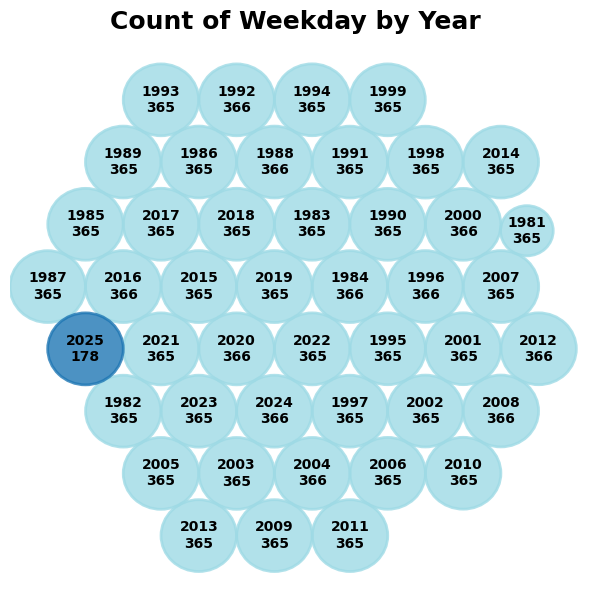

In [346]:
import pandas as pd
import matplotlib.pyplot as plt
import circlify
import matplotlib.cm as cm
import numpy as np
 
# Load dataset
df = pd.read_excel(r"D:\Akhila\ADQ\SENSEX\VERSION_4\Datasets\Sensex_with weekends(1981 to 27-06-2025).xlsx")
 
# Clean and prepare data
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)
 
# Extract Year and count trading days per year
df['Year'] = df['Date'].dt.year
yearly_counts = df.groupby('Year').size().reset_index(name='Count')
 
# Format for circlify
data = [{'year': str(row['Year']), 'days': row['Count']} for _, row in yearly_counts.iterrows()]
 
# Generate circles
circles = circlify.circlify(
    data,
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1),
    datum_field='days',
    id_field='year'
)
 
# Create color map
norm = plt.Normalize(min(row['days'] for row in data), max(row['days'] for row in data))
colors = [cm.tab20(norm(row['days'])) for row in data]
 
# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')
 
# Limit for plot
lim = max(max(abs(circle.x) + circle.r, abs(circle.y) + circle.r) for circle in circles)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
 
# Draw circles
for circle, row, color in zip(circles, data, colors):
    x, y, r = circle.x, circle.y, circle.r
    ax.add_patch(plt.Circle((x, y), r, alpha=0.8, color=color, linewidth=2, edgecolor='black'))
    plt.text(x, y, f"{row['year']}\n{row['days']}", ha='center', va='center', fontsize=10, weight='bold')
 
plt.title('Count of Weekday by Year', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
